In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MultipleLocator, FuncFormatter

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Lines / markers
    "lines.linewidth": 1.0,
    "lines.markersize": 4,

})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[1]
sys.path.append(str(project_root))

#Local imports
from single_photon_renormalization.scripts_experiments.reflection_vs_bandwidth import run_reflection_vs_bandwidth

<h1> Execute the experiment </h1>

Prepare the parameters

In [5]:
#Physical parameters
omega_A = 10*pi
gamma_A = 1*pi

param_cavity = {'omega_A': 10*np.pi, 'gamma_A': np.pi, 'L': 100}

param_time_evol = {'T': 50, 'dt': 0.01}


#Different photon frequencies
omega_p_tab = [10*pi, 9.75*pi, 9.5*pi]

#Prepare a tab of IR and UV cutoffs for each experiment
nb_pts_bandwith = 30
ir_tab_list = []
uv_tab_list = []


central_freqs = [10*pi, 8*pi, 6*pi, 4*pi]
for i in range(4):
    bandwith_tab = np.linspace(pi, 40*pi, nb_pts_bandwith)
    ir_tab_list.append(central_freqs[i] - bandwith_tab)
    uv_tab_list.append(central_freqs[i] + bandwith_tab)

Run all the experiments

In [ ]:
correction = True

for i in range(4):
    for j in range(3):
        print(f"Experiment with central frequency {central_freqs[i]/pi}*pi and photon frequency {omega_p_tab[j]/pi}*pi")
        param_photon = {'omega_p': omega_p_tab[j], 'delta_k': 0.05*np.pi, 'x_0': -25} 

        _, _, _ = run_reflection_vs_bandwidth(param_photon, param_cavity, param_time_evol, ir_tab_list[i], uv_tab_list[i],
                                              index_experiment=i+1, 
                                              index_omega_p=j+1,
                                              correction=correction)

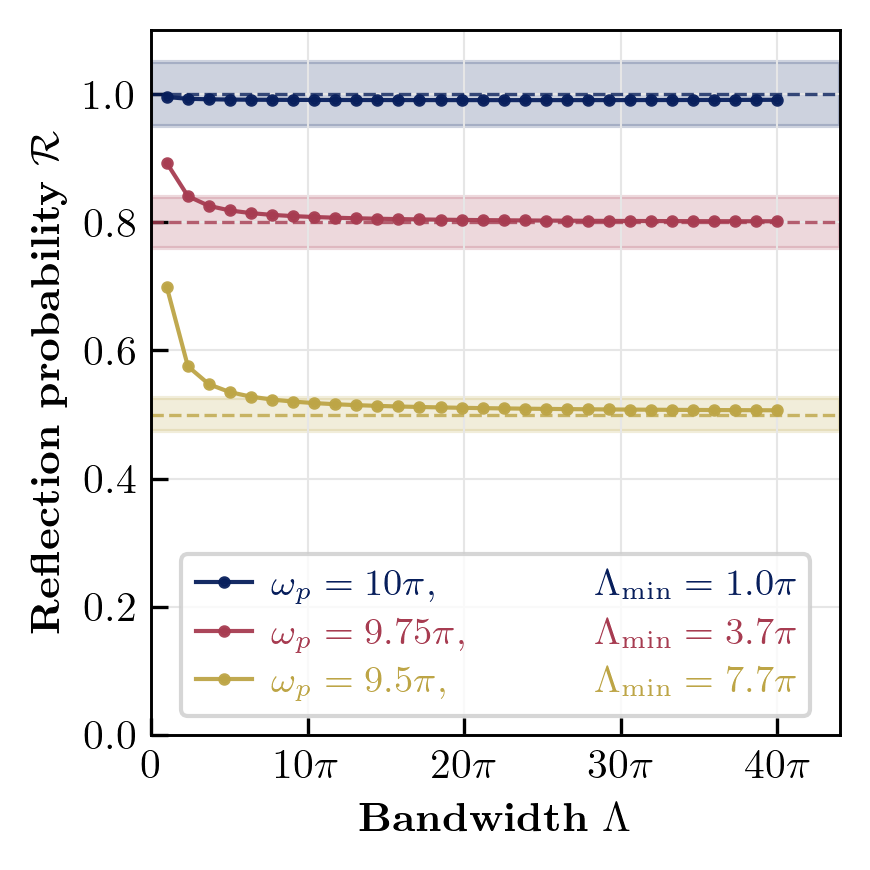

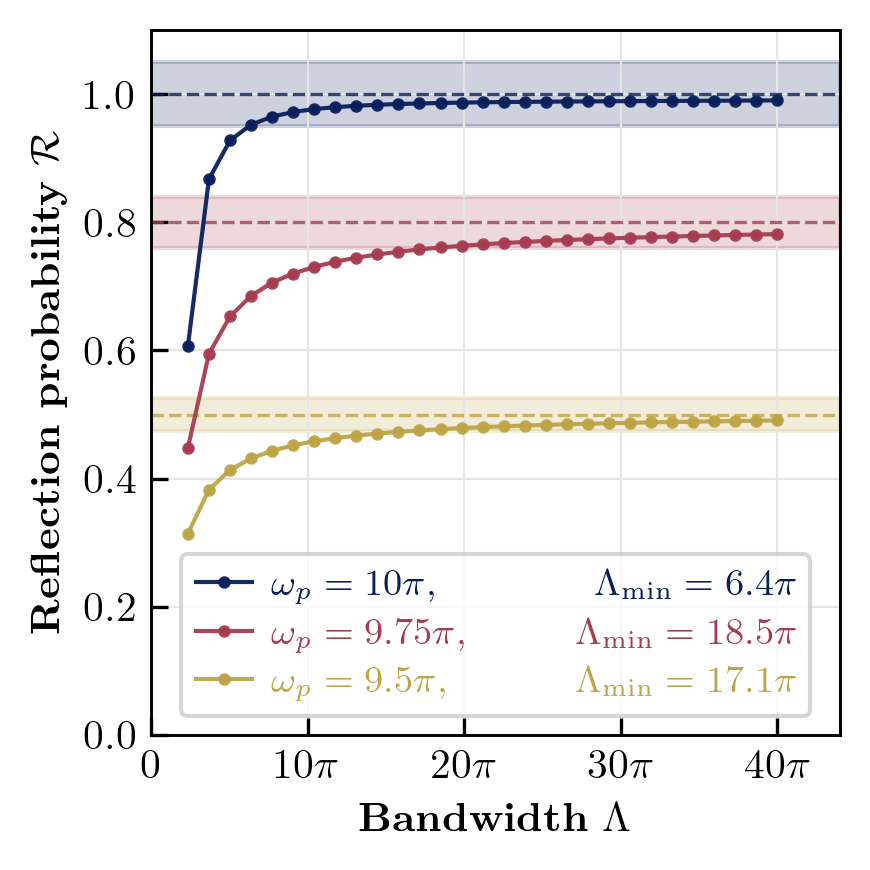

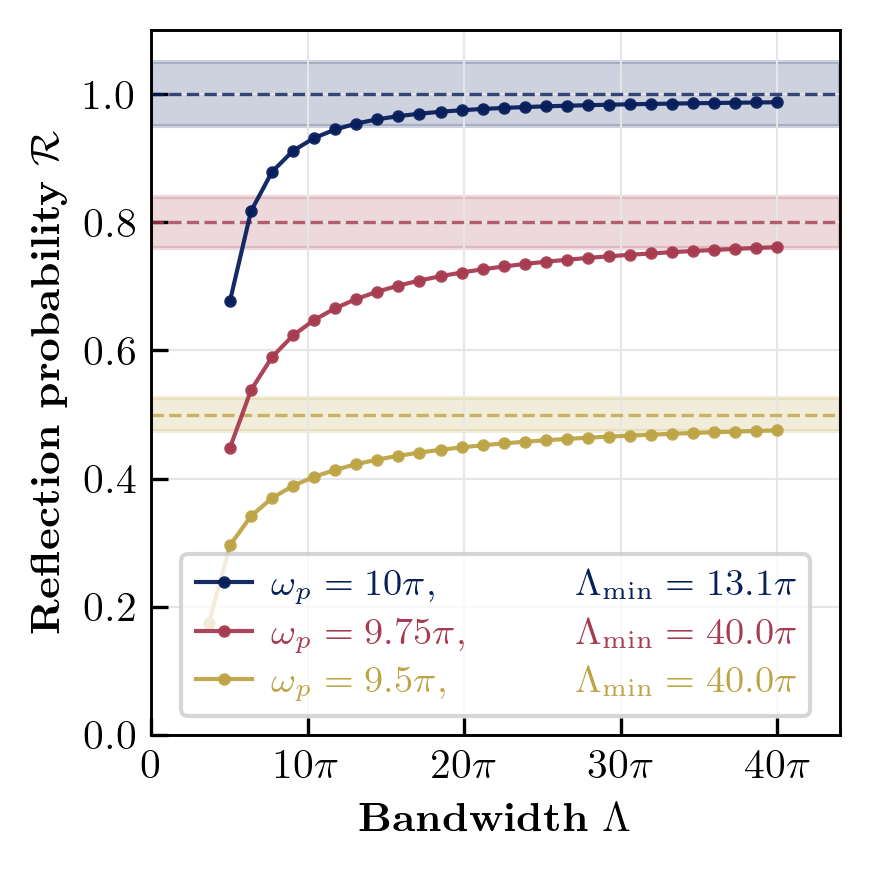

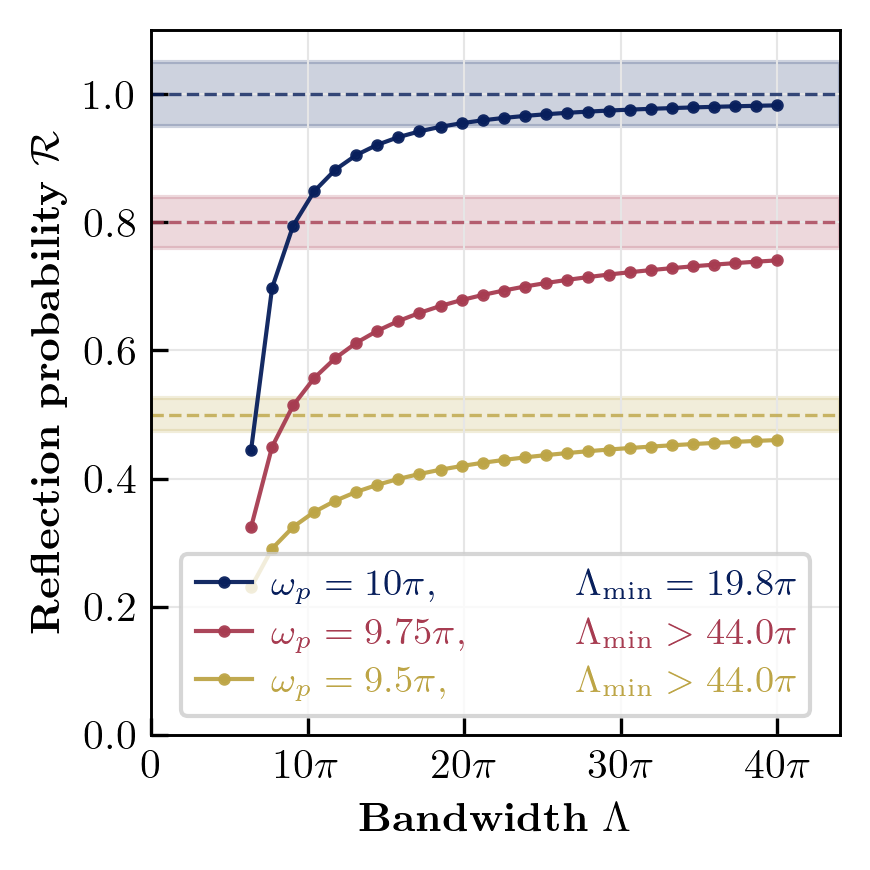

In [8]:
index_experiment_to_plot = [1,2,3,4]  
correction = False
max_x = 44*pi
colors = ['#081f5c', '#a73c51', '#bda546']

for index_experiment in index_experiment_to_plot:

    #Prepare the figure
    fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
    omega_labels = [r'$\omega_p = 10\pi$,', r'$\omega_p = 9.75\pi,$', r'$\omega_p = 9.5\pi$,']

    # Charger les données
    for j in range(3):
        index_omega_p = j+1

        if correction:
            data_file = f"../results/csv_files/reflection_vs_bandwidth/reflection_vs_bandwidth_omega{index_omega_p}_xp{index_experiment}_corrected.csv"
        else:
            data_file = f"../results/csv_files/reflection_vs_bandwidth/reflection_vs_bandwidth_omega{index_omega_p}_xp{index_experiment}_uncorrected.csv"


        df = pd.read_csv(data_file)
        reflection_tab = df['reflection_tab'].to_numpy()
        ir_tab = df['ir_tab'].to_numpy()
        uv_tab = df['uv_tab'].to_numpy()
        bandwidth_tab = (uv_tab - ir_tab)/2

        theoretical_val = (gamma_A/2)**2/((omega_p_tab[j] - omega_A)**2 + (gamma_A/2)**2)
        relative_error_tab = np.abs(reflection_tab - theoretical_val)/theoretical_val

        #get the minimal bandwidth for which the relative error is below 5%
        bandwidth_ok = bandwidth_tab[relative_error_tab < 0.05]
        if len(bandwidth_ok) > 0:
            min_bandwidth = np.min(bandwidth_ok)
            legend_label = (
                rf"\makebox[6.2em][l]{{{omega_labels[j]}}}"
                rf"\makebox[7.5em][r]{{$\Lambda_{{\rm min}} = {min_bandwidth/np.pi:.1f}\pi$}}"
            )
        else:
            legend_label = (
                rf"\makebox[6.2em][l]{{{omega_labels[j]}}}"
                rf"\makebox[7.5em][r]{{$\Lambda_{{\rm min}} > {max_x/np.pi:.1f}\pi$}}"
            )

        ax.plot(bandwidth_tab,
                reflection_tab,
                marker='o',
                markersize=2,
                label=legend_label,
                color=colors[j],
                linewidth=1,
                alpha=0.95,
                zorder=3)

        ax.hlines(theoretical_val,
                  0,
                  max_x,
                  color=colors[j],
                  linestyle='--',
                  linewidth=0.8,
                  alpha=0.8,
                  zorder=2)

        ax.fill_between(x=np.linspace(0, max_x, 500),
                        y1=0.95*theoretical_val,
                        y2=1.05*theoretical_val,
                        color=colors[j],
                        alpha=0.2,
                        zorder=1)


        # Grille
        ax.grid(color='0.9', linestyle='-', linewidth=0.5)

        # Axes labels
        ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=11)
        ax.set_ylabel(r'\textbf{Reflection probability} $\mathcal{R}$', fontsize=11)

        # Tick styling
        ax.tick_params(axis='both', which='major', length=4, width=0.8, labelsize=9)
        ax.set_xlim([0, max_x])
        ax.set_ylim([0, 1.1])

        # Tick x en unités de π
        ax.xaxis.set_major_locator(MultipleLocator(10*np.pi))
        def pi_formatter(x, pos):
            n = x / np.pi
            if np.isclose(n, 0):
                return "0"
            elif np.isclose(n, 1):
                return r"$\pi$"
            else:
                return rf"${int(round(n))}\pi$"
        ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

            #font size
        for item in [ax.xaxis.label, ax.yaxis.label]:
            item.set_fontsize(10)

        for item in (ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(10)


    # Légende en deux colonnes alignées: omega_q | RE
    legend = ax.legend(prop={'size': 9},
                       loc="lower center",
                       frameon=True,
                       handlelength=1.5,
                       handletextpad=0.5,
                       labelspacing=0.35)
    for text, color in zip(legend.get_texts(), colors):
        text.set_color(color)

    plt.tight_layout()
    file_name = f"reflection_vs_bandwidth_xp{index_experiment}_" + ('corrected' if correction else 'uncorrected')
    plt.savefig(f"../results/fig/reflection_vs_bandwidth/{file_name}.pdf", bbox_inches='tight', pad_inches=0.2)
    plt.show()